In [1]:
import pandas as pd
import numpy as np
import seaborn as snp
import matplotlib as plt

In [2]:
df=pd.read_csv("E:/cdmi_pratice/Bengaluru_House_Data.csv")

In [3]:
df.isnull()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...
13315,False,False,False,False,False,False,False,False,False
13316,False,False,False,False,True,False,False,True,False
13317,False,False,False,False,False,False,False,False,False
13318,False,False,False,False,False,False,False,False,False


In [4]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [5]:
df = df.drop(columns=['society'])

In [6]:
df.isnull().sum()


area_type         0
availability      0
location          1
size             16
total_sqft        0
bath             73
balcony         609
price             0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 12710 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12710 non-null  object 
 1   availability  12710 non-null  object 
 2   location      12710 non-null  object 
 3   size          12710 non-null  object 
 4   total_sqft    12710 non-null  object 
 5   bath          12710 non-null  float64
 6   balcony       12710 non-null  float64
 7   price         12710 non-null  float64
dtypes: float64(3), object(5)
memory usage: 893.7+ KB
None


In [9]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

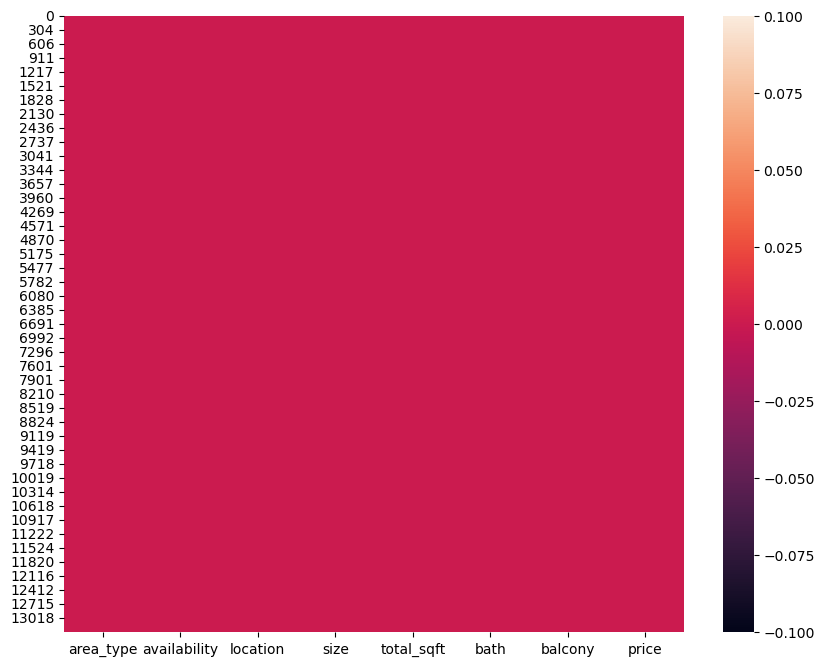

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))  
sns.heatmap(df.isnull())
plt.show()

In [11]:
x = df[['area_type','availability','location','size','total_sqft','bath','balcony']]
y = df['price']

In [12]:
x.shape,y.shape 

((12710, 7), (12710,))

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size= 1/3, random_state=0)


In [15]:
print(x_test,y_test)

                  area_type   availability                      location  \
10906  Super built-up  Area  Ready To Move                Seetharampalya   
12713        Built-up  Area  Ready To Move                      Kothanur   
551    Super built-up  Area         18-Apr                   Munnekollal   
6317         Built-up  Area  Ready To Move                    BTM Layout   
7284   Super built-up  Area  Ready To Move                Kanakpura Road   
...                     ...            ...                           ...   
9933             Plot  Area         19-Jan  Basaveshwara Nagar Yelahanka   
155    Super built-up  Area         18-Jul      Electronic City Phase II   
4223   Super built-up  Area  Ready To Move                   Hennur Road   
1257             Plot  Area  Ready To Move                    Whitefield   
5355   Super built-up  Area         19-Dec      Electronics City Phase 1   

            size total_sqft  bath  balcony  
10906      3 BHK       1798   3.0      3.0

In [16]:
x_train.shape,x_test.shape 
 

((8473, 7), (4237, 7))

In [17]:
y_train.shape,y_test.shape

((8473,), (4237,))

In [18]:
def convert_sqft_to_num(x):
    try:
        # Check if the value contains a range (e.g., '2100 - 2850')
        if '-' in x:
            tokens = x.split('-')
            # Convert both parts of the range to float and return the average
            return (float(tokens[0]) + float(tokens[1])) / 2
        # If it's a single number, return it as float
        return float(x)
    except:
        # If conversion fails (e.g., unknown formats), return NaN
        return np.nan

# Apply the conversion function to the 'total_sqft' column
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

# Drop rows where 'total_sqft' is NaN after conversion
df = df.dropna(subset=['total_sqft'])

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [20]:
categorical_cols = ['area_type', 'availability', 'location', 'size']

In [21]:
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(), categorical_cols)], remainder='passthrough')

In [22]:
x_encoded = preprocessor.fit_transform(df[['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath', 'balcony']])

In [23]:
y = df['price']

In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression()

In [26]:
regressor.intercept_ 

-23.16270763769387

In [27]:
regressor.coef_ 

array([-16.2075012 ,  -6.0690449 ,  35.20707169, ...,   0.0460218 ,
        16.37526976,   3.36744343])

In [28]:
y_pred = regressor.predict(x_test)
x_pred = regressor.predict(x_train)  

In [29]:
print(y_pred)
print(x_pred)

[102.67401138  52.56253245 203.74415376 ...  88.62626814 310.67402266
  53.62657451]
[273.6535574   40.2921012   32.73846792 ... 121.80193122  28.73561779
  37.2334059 ]


In [30]:
from sklearn.metrics import mean_squared_error,mean_absolute_error 

In [31]:
mse=mean_squared_error(y_test,y_pred) 
mae=mean_absolute_error(y_test,y_pred) 
rmse=np.sqrt(mse) 
print(mse) 
print(mae) 
print(rmse) 

10115.354873293738
37.496860598404375
100.57512054824363


In [32]:
import matplotlib.pyplot as plt

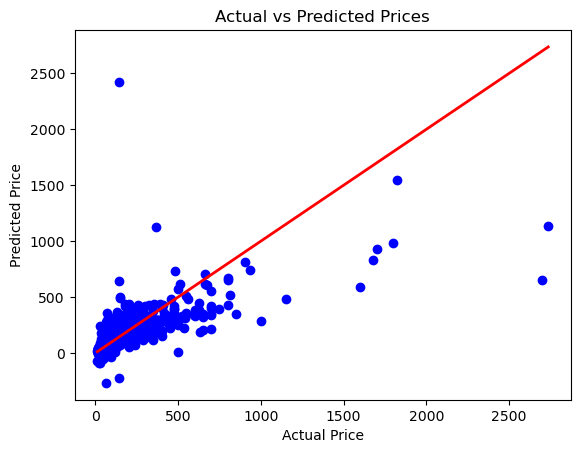

In [33]:
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()